# Laboratorio 1. Series de Tiempo

## Modelado de las series regionales

Fernando Rueda - 23748

Fernando Hernández - 23645

Este cuaderno cubre el inciso 4g del enunciado para las cuatro series de las que somos
responsables: el total de visitantes (serie obligatoria) y las tres regiones de `region_dos`,
América Del Centro, América Del Norte y Europa. Para cada una ajustamos una rejilla de modelos
SARIMA, comparamos por AIC, BIC y comportamiento de los residuos, y contrastamos con la
propuesta automática de `auto_arima`.

Parte del diagnóstico del cuaderno `analisis-series.ipynb`, que dejó como candidato de partida un
SARIMA(0,1,1)(0,1,1)₁₂ sobre el logaritmo, con d = 1 y período estacional 12 en las cuatro
series. Las dos regiones con meses en cero de 2020, América Del Norte y Europa, se modelan sobre
log(1 + x). Los algoritmos alternativos, la predicción sobre la prueba y la comparación por
métricas quedan para el cuaderno siguiente.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # los SARIMA de la rejilla avisan sobre convergencia sin afectar el resultado

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURAS = RAIZ / "reports" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = PALETA
GRIS = "#8a8a85"

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e4e0",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "font.size": 10,
    "legend.frameon": False,
})

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(FIGURAS / f"{nombre}.png", bbox_inches="tight", facecolor="white")

pd.set_option("display.width", 160)

In [2]:
train = pd.read_csv(RAIZ / "data" / "processed" / "series_train.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")

# El total y América Del Centro no tienen ceros y van sobre log; Norte y Europa traen los cinco
# meses en cero del cierre de 2020 y van sobre log(1 + x), como fijó el análisis preliminar.
SERIES = {
    "total": np.log(train["total"]),
    "region: América Del Centro": np.log(train["region: América Del Centro"]),
    "region: América Del Norte": np.log1p(train["region: América Del Norte"]),
    "region: Europa": np.log1p(train["region: Europa"]),
}
print(f"Entrenamiento: {train.index.min():%Y-%m} a {train.index.max():%Y-%m}, {len(train)} meses")
for nombre, y in SERIES.items():
    print(f"  {nombre:32s} transform={'log1p' if 'Norte' in nombre or 'Europa' in nombre else 'log'}")

Entrenamiento: 2009-01 a 2021-03, 147 meses
  total                            transform=log
  region: América Del Centro       transform=log
  region: América Del Norte        transform=log1p
  region: Europa                   transform=log1p


## 1. Metodología

**Candidatos.** El análisis preliminar dejó como punto de partida el SARIMA(0,1,1)(0,1,1)₁₂
sobre el log, con la parte regular sugerida por el rezago 1 negativo de los correlogramas y la
estacional por el rezago 12. Alrededor de ese candidato ajustamos la misma rejilla de nueve
modelos que se usó en las fronteras, para que la comparación sea homogénea entre las siete
series: variantes AR contra MA en la parte regular (p, q en {0, 1, 2}), variantes AR contra MA
en la estacional (P, Q en {0, 1}), y dos variantes con D = 0 para las series donde el análisis
preliminar dejó la diferencia estacional como opcional.

**Comparación.** AIC y BIC comparan el ajuste penalizando parámetros. Solo son comparables entre
modelos con la misma diferenciación, porque cambiar d o D cambia la serie sobre la que se calcula
la verosimilitud; por eso los modelos con D = 0 se evalúan aparte. El segundo criterio es la
prueba de Ljung-Box sobre los residuos: un buen modelo deja residuos sin autocorrelación
(p > 0.05 significa residuos compatibles con ruido blanco).

**Advertencia sobre el tramo pandémico.** Los últimos doce meses del entrenamiento son el
colapso de 2020. Ningún SARIMA con estacionalidad fija puede seguir una caída de esa magnitud,
así que los residuos de 2020 van a ser grandes en todas las especificaciones. El caso es más
severo en América Del Norte y Europa, cuyos cinco meses en cero se vuelven, en escala log(1 + x),
cinco residuos enormes: el modelo predice un nivel normal y la serie vale cero. Eso no distingue
entre candidatos, los castiga a todos por igual, pero sí contamina las pruebas de residuos, como
se verá en esas dos series.

In [3]:
CANDIDATOS = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 2), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((0, 1, 1), (0, 1, 0, 12)),
    ((0, 1, 2), (0, 1, 0, 12)),
    ((0, 1, 1), (1, 0, 1, 12)),   # D = 0
    ((1, 1, 1), (1, 0, 1, 12)),   # D = 0
]


def etiqueta(orden, sorden):
    return f"SARIMA{orden}x{sorden[:3]}12"


def ajustar_rejilla(y):
    """Ajusta los candidatos y devuelve la tabla de comparación y los resultados."""
    filas, ajustes = [], {}
    for orden, sorden in CANDIDATOS:
        r = SARIMAX(y, order=orden, seasonal_order=sorden).fit(disp=False)
        resid = r.resid[r.loglikelihood_burn:]
        filas.append({
            "modelo": etiqueta(orden, sorden),
            "D": sorden[1],
            "AIC": round(r.aic, 1),
            "BIC": round(r.bic, 1),
            "Ljung-Box p (12)": round(acorr_ljungbox(resid, lags=[12]).iloc[0, 1], 3),
            "Ljung-Box p (24)": round(acorr_ljungbox(resid, lags=[24]).iloc[0, 1], 3),
        })
        ajustes[etiqueta(orden, sorden)] = r
    tabla = pd.DataFrame(filas).set_index("modelo").sort_values(["D", "AIC"], ascending=[False, True])
    return tabla, ajustes


def diagnostico_residuos(resultado, titulo, nombre_figura):
    fig = resultado.plot_diagnostics(figsize=(11, 7), lags=24)
    fig.suptitle(titulo, y=1.0)
    guardar(nombre_figura)
    plt.show()

## 2. Total de visitantes

### 2.1 Rejilla de modelos SARIMA

In [4]:
tabla_total, ajustes_total = ajustar_rejilla(SERIES["total"])
tabla_total

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,64.1,72.8,0.215,0.856
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,67.9,76.6,0.173,0.796
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,68.0,76.7,0.169,0.793
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,69.2,80.8,0.261,0.870
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,69.6,81.2,0.206,0.829
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,87.8,93.6,0.053,0.417
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,88.8,97.5,0.083,0.504
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,67.2,79.1,0.420,0.933
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,69.1,84.0,0.447,0.941


Entre los modelos con D = 1, comparables entre sí, el mejor AIC es el
**SARIMA(0,1,1)(1,1,0)₁₂** con 64.1, claramente por delante del airline SARIMA(0,1,1)(0,1,1)₁₂
(68.0) y del SARIMA(1,1,0)(0,1,1)₁₂ (67.9). El BIC ordena igual y agregar órdenes solo empeora el
criterio. El modelo sin ningún término estacional, SARIMA(0,1,1)(0,1,0)₁₂, salta a 87.8: hay
estructura estacional que el término AR estacional sí captura.

El mejor D = 0, SARIMA(0,1,1)(1,0,1)₁₂ con AIC 67.2, no le gana al mejor D = 1 pese a tener
residuos algo más limpios (Ljung-Box 0.420), así que nos quedamos con D = 1. Y a diferencia de
varias fronteras, aquí los residuos aprueban con holgura: **Ljung-Box de 0.215 en el rezago 12 y
0.856 en el 24**. El total es una de las series mejor comportadas.

### 2.2 Residuos del modelo elegido

findfont: Failed to find font weight semibold, now using 700.


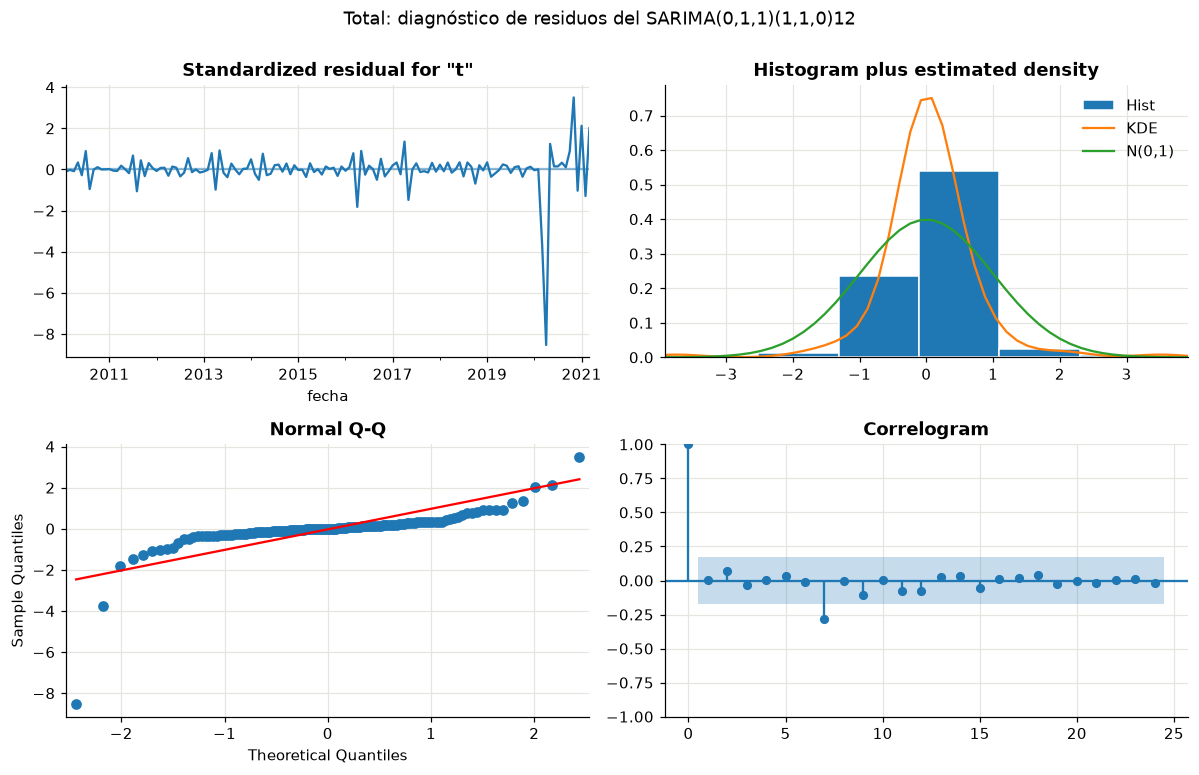

Los tres residuos más grandes (en log):
fecha
2020-04-01    2.50
2020-03-01    1.09
2020-11-01    1.02


In [5]:
mejor_total = ajustes_total["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_total, "Total: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-total-residuos")
resid = mejor_total.resid[mejor_total.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

El residuo dominante es **abril de 2020 con 2.5 desviaciones**, el primer mes pleno del cierre,
seguido de marzo y noviembre de 2020, todos por debajo de las magnitudes que veremos en las
regiones con ceros. El correlograma de residuos queda dentro de la banda y el QQ-plot es
razonablemente recto salvo las colas de 2020. La autocorrelación residual no es problema aquí.

**Elegido para el total: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.** Interpretación: tras quitar
tendencia (d = 1) y estacionalidad (D = 1), cada mes se corrige con el error del mes anterior
(término MA regular) y con lo ocurrido el mismo mes del año pasado (término AR estacional).

### 2.3 Contraste con auto_arima

In [6]:
auto_total = pm.auto_arima(SERIES["total"], seasonal=True, m=12,
                           stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_total.order}x{auto_total.seasonal_order} | AIC {auto_total.aic():.1f}")
auto_total.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 0, 1)x(1, 0, 2, 12) | AIC 66.2


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.0720,0.144,0.499,0.618,-0.211,0.355
ar.L1,0.9031,0.036,24.961,0.000,0.832,0.974
ma.L1,0.1431,0.094,1.516,0.129,-0.042,0.328
ar.S.L12,0.9376,0.122,7.691,0.000,0.699,1.177
ma.S.L12,-0.9238,0.277,-3.335,0.001,-1.467,-0.381
ma.S.L24,0.2049,0.297,0.691,0.490,-0.376,0.786
sigma2,0.0773,0.006,12.723,0.000,0.065,0.089


`auto_arima` propone un ARIMA(1,0,1)(1,0,2)₁₂ con **d = 0 y D = 0**. Es el mismo error que se vio
en las fronteras: su prueba de raíz unitaria por defecto (KPSS) lee el colapso pandémico como
ausencia de tendencia y no diferencia, compensando con partes AR y MA sobre una serie que sí
tiene tendencia. Su AIC (66.2) ni siquiera es comparable con el nuestro, porque se calcula sobre
una serie distinta, la no diferenciada. Nuestro diagnóstico manual con ADF más correlogramas
produjo un modelo más simple y correctamente diferenciado.

## 3. América Del Centro

### 3.1 Rejilla de modelos SARIMA

In [7]:
tabla_centro, ajustes_centro = ajustar_rejilla(SERIES["region: América Del Centro"])
tabla_centro

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,50.4,59.1,0.268,0.855
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,55.5,64.2,0.205,0.763
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,55.5,64.2,0.206,0.763
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,57.3,68.9,0.241,0.790
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,57.4,69.0,0.218,0.773
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,76.8,82.5,0.050,0.287
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,77.9,86.6,0.084,0.368
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,54.6,66.5,0.366,0.870
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,56.6,71.5,0.367,0.870


Mismo cuadro que el total, y más marcado. El **SARIMA(0,1,1)(1,1,0)₁₂** gana con AIC 50.4, cinco
puntos por delante del siguiente (55.5), una diferencia esta vez sí concluyente. El BIC coincide
y los residuos aprueban con holgura (**Ljung-Box 0.268 en el 12, 0.855 en el 24**). Los modelos
D = 0 no compiten. Que la región que aporta el 73% del total elija exactamente el mismo modelo
que el total no sorprende: el total hereda su forma.

### 3.2 Residuos del modelo elegido

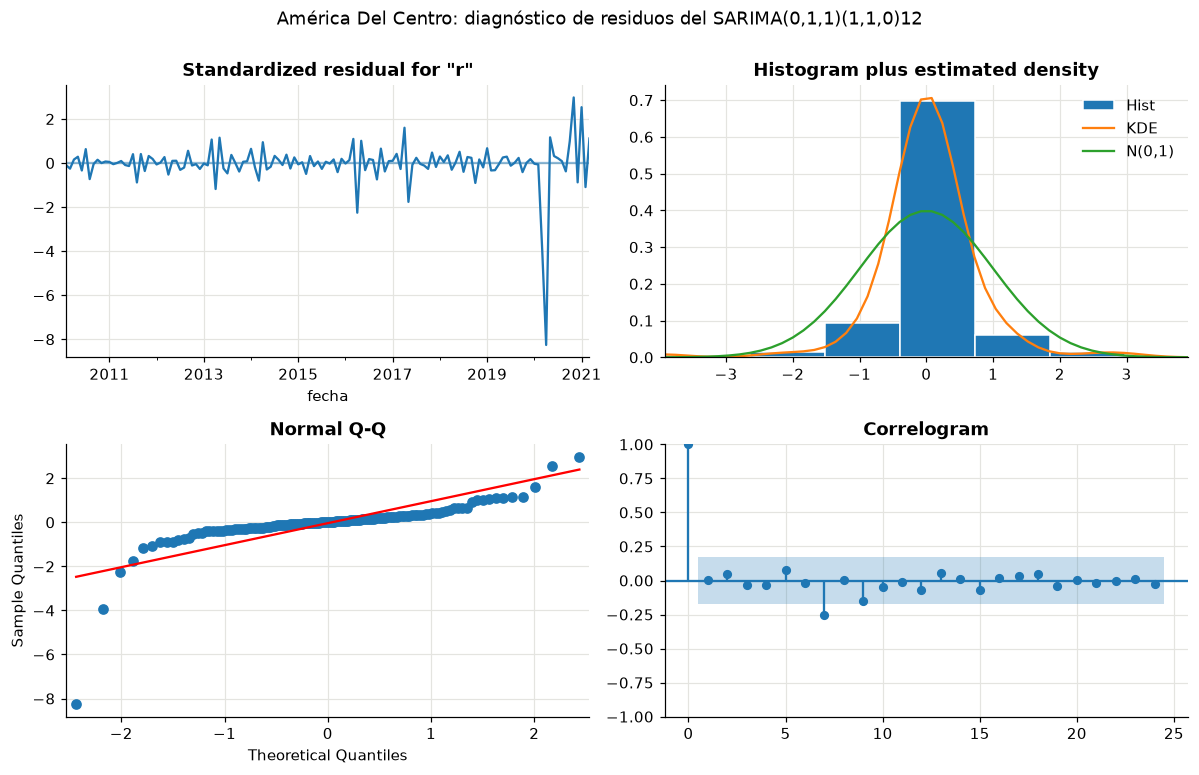

Los tres residuos más grandes (en log):
fecha
2020-04-01    2.30
2020-03-01    1.10
2020-11-01    0.83


In [8]:
mejor_centro = ajustes_centro["SARIMA(0, 1, 1)x(1, 1, 0)12"]
diagnostico_residuos(mejor_centro, "América Del Centro: diagnóstico de residuos del SARIMA(0,1,1)(1,1,0)12",
                     "modelado-centro-residuos")
resid = mejor_centro.resid[mejor_centro.loglikelihood_burn:]
print("Los tres residuos más grandes (en log):")
print(resid.abs().nlargest(3).round(2).to_string())

Residuos casi calcados a los del total, con abril de 2020 (2.3 desviaciones) a la cabeza y el
resto del correlograma limpio. Nada que el modelo deje sin capturar fuera del cambio de régimen.

**Elegido para América Del Centro: SARIMA(0,1,1)(1,1,0)₁₂ sobre el log.**

### 3.3 Contraste con auto_arima

In [9]:
auto_centro = pm.auto_arima(SERIES["region: América Del Centro"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_centro.order}x{auto_centro.seasonal_order} | AIC {auto_centro.aic():.1f}")
auto_centro.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 0, 1)x(1, 0, 2, 12) | AIC 54.1


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,0.1247,0.180,0.694,0.488,-0.228,0.477
ar.L1,0.8966,0.038,23.645,0.000,0.822,0.971
ma.L1,0.1397,0.094,1.482,0.138,-0.045,0.324
ar.S.L12,0.8942,0.154,5.807,0.000,0.592,1.196
ma.S.L12,-0.7720,0.297,-2.601,0.009,-1.354,-0.190
ma.S.L24,0.1773,0.304,0.583,0.560,-0.419,0.773
sigma2,0.0728,0.006,11.397,0.000,0.060,0.085


Otra vez `auto_arima` cae en d = 0 (ARIMA(1,0,1)(1,0,2)₁₂), por la misma lectura errónea de la
tendencia. La supervisión manual vuelve a ser necesaria: con un cambio de régimen en la serie, la
selección automática necesita que se le fije la diferenciación.

## 4. América Del Norte

### 4.1 Rejilla de modelos SARIMA

In [10]:
tabla_norte, ajustes_norte = ajustar_rejilla(SERIES["region: América Del Norte"])
tabla_norte

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,412.2,418.0,0.0,0.025
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,412.8,421.5,0.0,0.055
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,413.0,421.7,0.0,0.023
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,413.0,421.7,0.0,0.024
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,413.1,421.8,0.0,0.025
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,413.8,425.4,0.0,0.053
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,414.7,426.3,0.0,0.026
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,439.2,451.1,0.0,0.034
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,440.8,455.7,0.0,0.038


Aquí el cuadro cambia por los ceros. Entre los D = 1 gana el modelo **más simple**,
SARIMA(0,1,1)(0,1,0)₁₂ con AIC 412.2, y los siguientes seis quedan todos en un punto (412.8 a
413.8): el término AR o MA estacional no aporta ajuste apreciable, porque la diferencia estacional
ya absorbió la estacionalidad y no queda estructura estacional que modelar. Aun así los D = 1 le
ganan claramente a los D = 0 (439), así que la diferencia estacional que el preliminar dejó como
opcional queda confirmada como conveniente por AIC.

Lo que no aprueba son los residuos: **Ljung-Box da 0.0 en el rezago 12 para todos los
candidatos**. Ningún orden lo arregla porque la causa no es el orden, es el bloque de cinco meses
en cero, como se ve abajo.

### 4.2 Residuos del modelo elegido

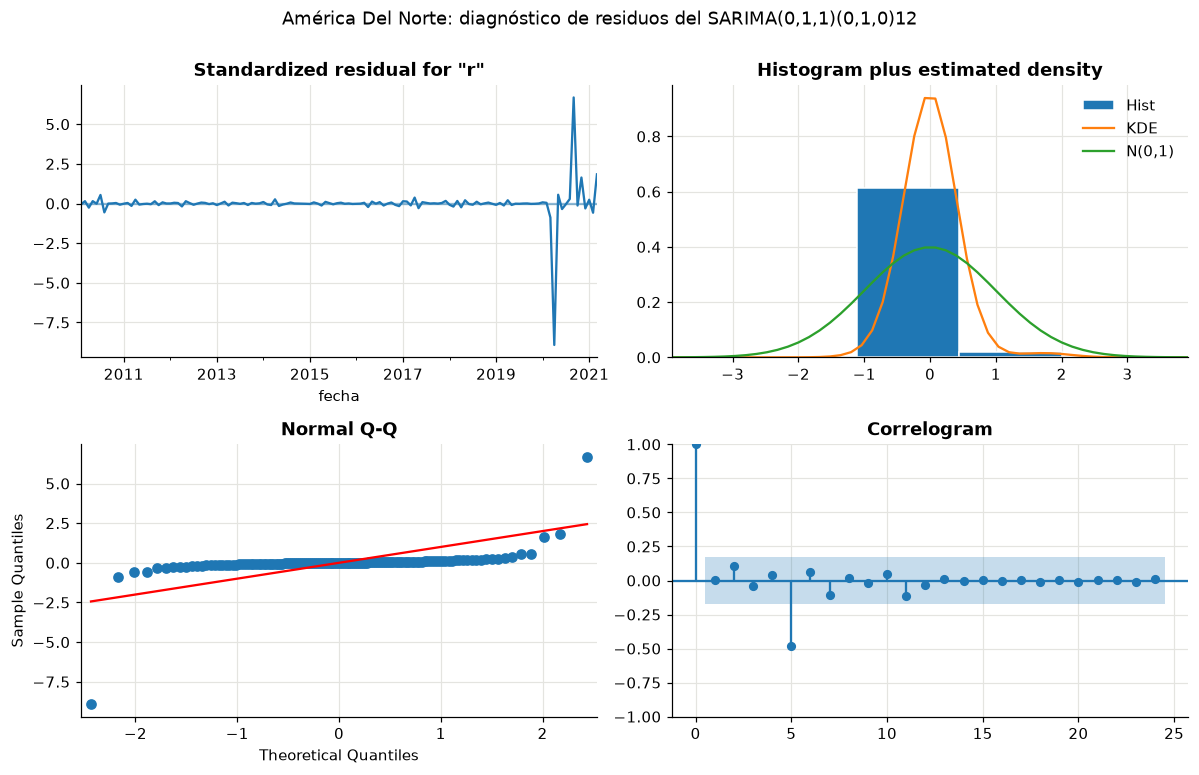

Los tres residuos más grandes (en log(1+x)):
fecha
2020-04-01    9.90
2020-09-01    7.42
2021-03-01    2.04


In [11]:
mejor_norte = ajustes_norte["SARIMA(0, 1, 1)x(0, 1, 0)12"]
diagnostico_residuos(mejor_norte, "América Del Norte: diagnóstico de residuos del SARIMA(0,1,1)(0,1,0)12",
                     "modelado-norte-residuos")
resid = mejor_norte.resid[mejor_norte.loglikelihood_burn:]
print("Los tres residuos más grandes (en log(1+x)):")
print(resid.abs().nlargest(3).round(2).to_string())

Los residuos gigantes lo explican todo: **abril de 2020 con 9.9 desviaciones y septiembre con
7.4**, los meses en cero, donde el modelo predice el nivel normal en log(1 + x) y la serie vale
cero. Cinco residuos de ese tamaño, correlacionados entre sí, disparan el Ljung-Box en el rezago
12 y engordan las colas del QQ-plot. Es exactamente el artefacto que vimos en La Aurora con el
cierre del aeropuerto, amplificado porque aquí son cinco meses consecutivos en cero y no uno.
Fuera del tramo pandémico los residuos se ven centrados y sin estructura. Lo aceptamos documentado
en lugar de inflar el modelo con órdenes que no significan nada.

**Elegido para América Del Norte: SARIMA(0,1,1)(0,1,0)₁₂ sobre log(1 + x).** Es la estructura
airline sin el término estacional que la serie no pide: diferencia regular, diferencia estacional
y un término MA regular de corrección.

### 4.3 Contraste con auto_arima

In [12]:
auto_norte = pm.auto_arima(SERIES["region: América Del Norte"], seasonal=True, m=12,
                           stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_norte.order}x{auto_norte.seasonal_order} | AIC {auto_norte.aic():.1f}")
auto_norte.summary().tables[1]

Propuesta de auto_arima: ARIMA(2, 1, 2)x(0, 1, 0, 12) | AIC 395.4


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,-1.3726,0.108,-12.717,0.000,-1.584,-1.161
ar.L2,-0.5351,0.104,-5.169,0.000,-0.738,-0.332
ma.L1,1.6281,0.093,17.528,0.000,1.446,1.810
ma.L2,0.8847,0.082,10.761,0.000,0.724,1.046
sigma2,1.0280,0.024,42.345,0.000,0.980,1.076


A diferencia del total y de Centro, aquí `auto_arima` **sí diferencia bien** (d = 1, D = 1): con
los ceros de por medio, su prueba ya no confunde la tendencia. Propone un ARIMA(2,1,2)(0,1,0)₁₂
con AIC 395.4, menor que el nuestro. Pero esos cuatro términos AR y MA no capturan una dinámica
real de la serie, capturan el zigzag del bloque pandémico: bajan el AIC ajustándose al colapso,
no al comportamiento normal. Preferimos el modelo simple, cuyo único defecto de residuos es el
mismo artefacto de los ceros que ningún orden elimina, antes que sobreajustar la anomalía.

### 4.4 Nota sobre América Del Norte

El caso de esta serie deja una lección metodológica: cuando el AIC premia órdenes que solo
modelan el tramo anómalo, el criterio de parsimonia y la interpretabilidad pesan más que el
número. Ninguno de los dos modelos, ni el simple ni el de auto_arima, tiene residuos limpios, así
que el desempate no lo da el ajuste sino la sencillez.

## 5. Europa

### 5.1 Rejilla de modelos SARIMA

In [13]:
tabla_europa, ajustes_europa = ajustar_rejilla(SERIES["region: Europa"])
tabla_europa

,D,AIC,BIC,Ljung-Box p (12),Ljung-Box p (24)
modelo,,,,,
"SARIMA(0, 1, 1)x(0, 1, 0)12",1,341.6,347.4,0.021,0.454
"SARIMA(1, 1, 0)x(0, 1, 1)12",1,342.5,351.2,0.025,0.482
"SARIMA(0, 1, 1)x(0, 1, 1)12",1,342.6,351.3,0.022,0.456
"SARIMA(0, 1, 1)x(1, 1, 0)12",1,342.9,351.6,0.020,0.444
"SARIMA(0, 1, 2)x(0, 1, 0)12",1,343.6,352.3,0.025,0.482
"SARIMA(1, 1, 1)x(0, 1, 1)12",1,344.5,356.1,0.027,0.499
"SARIMA(0, 1, 2)x(0, 1, 1)12",1,344.6,356.1,0.025,0.485
"SARIMA(0, 1, 1)x(1, 0, 1)12",0,365.4,377.3,0.013,0.362
"SARIMA(1, 1, 1)x(1, 0, 1)12",0,367.2,382.2,0.018,0.412


Igual que Norte, gana el modelo más simple, **SARIMA(0,1,1)(0,1,0)₁₂** con AIC 341.6, seguido de
cerca por el resto de los D = 1 (342.5 a 344.6). Los D = 0 quedan lejos (365), confirmando la
diferencia estacional que el preliminar había marcado como **obligatoria** para Europa. Los
residuos están al borde: **Ljung-Box 0.021 en el rezago 12** (falla por poco) pero **0.454 en el
24** (aprueba). El problema, otra vez, se concentra en unos pocos meses.

### 5.2 Residuos del modelo elegido

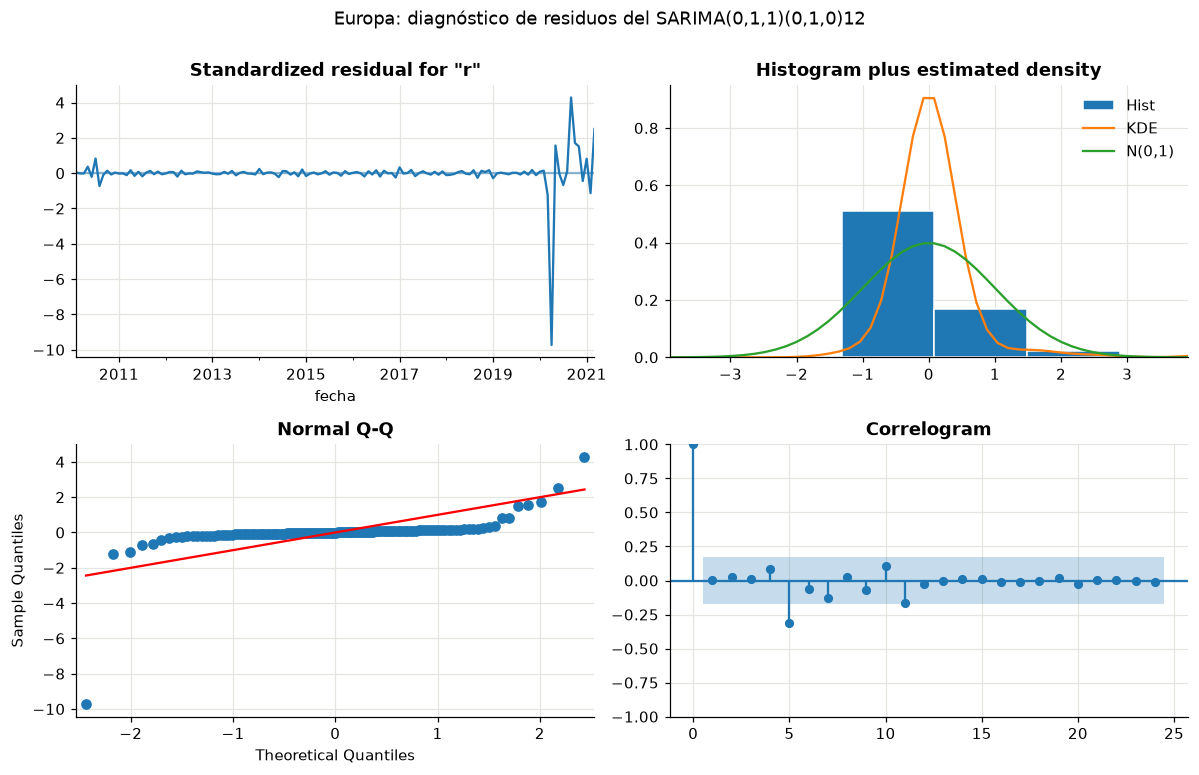

Los tres residuos más grandes (en log(1+x)):
fecha
2020-04-01    8.30
2020-09-01    3.66
2021-03-01    2.13


In [14]:
mejor_europa = ajustes_europa["SARIMA(0, 1, 1)x(0, 1, 0)12"]
diagnostico_residuos(mejor_europa, "Europa: diagnóstico de residuos del SARIMA(0,1,1)(0,1,0)12",
                     "modelado-europa-residuos")
resid = mejor_europa.resid[mejor_europa.loglikelihood_burn:]
print("Los tres residuos más grandes (en log(1+x)):")
print(resid.abs().nlargest(3).round(2).to_string())

El mismo diagnóstico que Norte, algo más leve: **abril de 2020 con 8.3 desviaciones** encabeza,
seguido de septiembre. Los ceros del cierre son la fuente del rezago 12 marginal; el resto del
correlograma está limpio y por eso el rezago 24 sí aprueba. Artefacto de los ceros, no dinámica
sin capturar.

**Elegido para Europa: SARIMA(0,1,1)(0,1,0)₁₂ sobre log(1 + x).**

### 5.3 Contraste con auto_arima

In [15]:
auto_europa = pm.auto_arima(SERIES["region: Europa"], seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action="ignore")
print(f"Propuesta de auto_arima: ARIMA{auto_europa.order}x{auto_europa.seasonal_order} | AIC {auto_europa.aic():.1f}")
auto_europa.summary().tables[1]

Propuesta de auto_arima: ARIMA(1, 1, 0)x(0, 1, 0, 12) | AIC 341.6


,coef,std err,z,P>|z|,[0.025,0.975]
ar.L1,0.1290,0.054,2.384,0.017,0.023,0.235
sigma2,0.7270,0.018,40.945,0.000,0.692,0.762


En Europa `auto_arima` **coincide con nuestro diagnóstico**: propone un ARIMA(1,1,0)(0,1,0)₁₂,
con la misma diferenciación (d = 1, D = 1) y sin términos estacionales, prácticamente el mismo
modelo que elegimos, apenas cambiando el término regular de MA por AR. Es la confirmación de que,
cuando los ceros impiden que la prueba de raíz unitaria confunda la tendencia, la selección
automática llega al mismo lugar que el análisis manual.

## 6. Resumen del modelado ARIMA de regiones

| Serie | Transform | Modelo elegido | AIC | BIC | Ljung-Box p (12 / 24) |
|---|---|---|---|---|---|
| Total | log | SARIMA(0,1,1)(1,1,0)₁₂ | 64.1 | 72.8 | 0.215 / 0.856 |
| América Del Centro | log | SARIMA(0,1,1)(1,1,0)₁₂ | 50.4 | 59.1 | 0.268 / 0.855 |
| América Del Norte | log(1+x) | SARIMA(0,1,1)(0,1,0)₁₂ | 412.2 | 418.0 | 0.000 / 0.025 |
| Europa | log(1+x) | SARIMA(0,1,1)(0,1,0)₁₂ | 341.6 | 347.4 | 0.021 / 0.454 |

Tres lecturas cierran esta parte.

**Los ceros parten las cuatro series en dos grupos.** El total y América Del Centro, sin ceros,
eligen un modelo con término AR estacional (0,1,1)(1,1,0)₁₂ y dejan residuos limpios que aprueban
Ljung-Box con holgura. América Del Norte y Europa, con cinco meses en cero, eligen el modelo más
simple sin término estacional (0,1,1)(0,1,0)₁₂ y arrastran residuos que fallan o rozan la prueba,
no por mala especificación sino por el bloque pandémico que en log(1 + x) se vuelve un grupo de
residuos enormes. La estructura de fondo es la misma airline en las cuatro; lo que cambia es cuánto
la contamina el cierre.

**auto_arima acertó solo cuando los ceros le impidieron equivocarse.** En el total y en Centro
fue a d = 0, la misma falla de las fronteras: la prueba KPSS lee el colapso como ausencia de
tendencia. En Norte y Europa, donde los ceros vuelven la tendencia inconfundible, diferenció bien;
en Europa incluso coincidió con nuestro modelo, y en Norte propuso órdenes que sobreajustan el
tramo pandémico. La conclusión es la misma que en fronteras: con un cambio de régimen, la
selección automática necesita supervisión.

**Los candidatos del preliminar iban bien encaminados.** En ninguna de las cuatro series la
rejilla encontró algo sustancialmente mejor que el SARIMA(0,1,1)(0,1,1)₁₂ leído de los
correlogramas; los ganadores son variantes menores de ese punto de partida. La diferencia
estacional opcional de América Del Norte quedó confirmada como conveniente, y la obligatoria de
Europa, confirmada como necesaria.

El cuaderno siguiente toma estos cuatro modelos elegidos, los enfrenta a Prophet, Holt-Winters,
suavizamiento exponencial y seasonal naive, y evalúa la predicción sobre el conjunto de prueba.

## 7. Modelos alternativos y pronóstico sobre la prueba

Ajustamos ahora los algoritmos del inciso 4h para las cuatro series: **Prophet**, **Holt-Winters**
(con y sin amortiguamiento de tendencia), **suavizamiento exponencial simple** y **seasonal
naive**. Todos se entrenan con los mismos 147 meses y pronostican los 63 meses de la prueba
(abril 2021 a junio 2026) de una sola vez, sin ver ningún dato de ese período. Todos trabajan en
la escala transformada de su serie, `log` para el total y América Del Centro, `log(1 + x)` para
América Del Norte y Europa, salvo el seasonal naive que repite tal cual los últimos doce meses
observados. Las métricas MAE y RMSE se calculan en la escala original de visitantes.

Es el mismo escenario difícil de las fronteras: el entrenamiento termina en el piso pandémico y
el horizonte es de cinco años. Ningún algoritmo tiene información para anticipar la reapertura,
así que lo que se compara aquí es qué supuesto de continuación falla menos.

In [16]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)  # prophet imprime el log de stan por defecto

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing

test = pd.read_csv(RAIZ / "data" / "processed" / "series_test.csv", parse_dates=["fecha"]).set_index("fecha").asfreq("MS")
H = len(test)

# Cada serie lleva su par (transformada, inversa): log/exp para las limpias, log1p/expm1 para
# las que traen ceros. Es la misma transformación con que se ajustaron los SARIMA.
TRANSFORM = {
    "total": (np.log, np.exp),
    "region: América Del Centro": (np.log, np.exp),
    "region: América Del Norte": (np.log1p, np.expm1),
    "region: Europa": (np.log1p, np.expm1),
}


def pronosticos_alternativos(nombre, resultado_sarima):
    """Pronóstico estático de 63 meses con cada algoritmo, en escala original."""
    fwd, inv = TRANSFORM[nombre]
    y, ylog = train[nombre], fwd(train[nombre])
    idx = test.index
    preds = {"SARIMA elegido": inv(resultado_sarima.forecast(H))}
    hw = ExponentialSmoothing(ylog, trend="add", seasonal="add", seasonal_periods=12).fit()
    preds["Holt-Winters"] = inv(hw.forecast(H))
    hwd = ExponentialSmoothing(ylog, trend="add", damped_trend=True, seasonal="add",
                               seasonal_periods=12).fit()
    preds["Holt-Winters amortiguado"] = inv(hwd.forecast(H))
    preds["Suav. exponencial simple"] = inv(SimpleExpSmoothing(ylog).fit().forecast(H))
    m = Prophet(seasonality_mode="additive", yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False)
    m.fit(pd.DataFrame({"ds": ylog.index, "y": ylog.values}))
    futuro = m.make_future_dataframe(periods=H, freq="MS")
    preds["Prophet"] = pd.Series(inv(m.predict(futuro)["yhat"].values[-H:]), index=idx)
    preds["Seasonal naive"] = pd.Series(np.tile(y.iloc[-12:].values, 6)[:H], index=idx)
    return {k: pd.Series(np.asarray(v), index=idx) for k, v in preds.items()}


def tabla_errores(nombre, preds):
    yt = test[nombre]
    filas = {}
    for k, p in preds.items():
        e = yt.values - p.values
        filas[k] = {"MAE": round(np.mean(np.abs(e))), "RMSE": round(np.sqrt(np.mean(e ** 2))),
                    "pred. media": round(p.mean()), "real medio": round(yt.mean())}
    return pd.DataFrame(filas).T.sort_values("MAE")


COLORES_MODELO = {"SARIMA elegido": NARANJA, "Holt-Winters amortiguado": AQUA,
                  "Suav. exponencial simple": AMARILLO, "Prophet": MAGENTA, "Seasonal naive": GRIS}


def graficar_pronosticos(nombre, preds, nombre_figura):
    yt = test[nombre]
    fig, eje = plt.subplots(figsize=(12, 4.6))
    eje.plot(train[nombre].iloc[-36:], color=AZUL, lw=1.4, label="entrenamiento (últimos 3 años)")
    eje.plot(yt, color="#222222", lw=1.8, label="real (prueba)")
    for k, color in COLORES_MODELO.items():
        eje.plot(preds[k], color=color, lw=1.1, ls="--", label=k)
    eje.set_title(f"{nombre}: pronóstico estático de 63 meses contra la realidad")
    eje.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    eje.legend(loc="upper left", fontsize=8)
    guardar(nombre_figura)
    plt.show()

Importing plotly failed. Interactive plots will not work.


### 7.1 Total

20:39:45 - cmdstanpy - INFO - Chain [1] start processing


20:39:45 - cmdstanpy - INFO - Chain [1] done processing


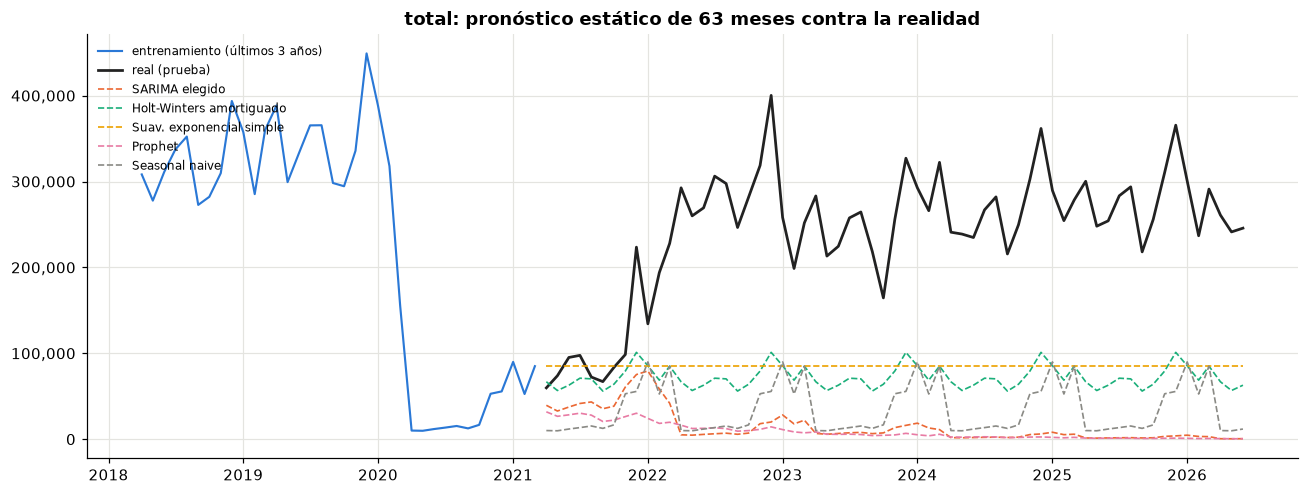

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,158777,173709,85017,241617
Holt-Winters amortiguado,170053,183865,71790,241617
Holt-Winters,178392,192825,63446,241617
Seasonal naive,207322,219664,34296,241617
SARIMA elegido,226894,243234,14723,241617
Prophet,232826,246743,8791,241617


In [17]:
preds_total = pronosticos_alternativos("total", mejor_total)
graficar_pronosticos("total", preds_total, "modelado-total-pronosticos")
tabla_errores("total", preds_total)

Todos los modelos subestiman: el nivel medio real de la prueba es 241,617 visitantes al mes y la
mejor predicción media queda muy por debajo. Gana el **suavizamiento exponencial simple** (MAE
158,777), otra vez por anclaje, su línea plana parte del último nivel observado, que en el total
ya recuperaba cerca del 25%. Le siguen los Holt-Winters (170 a 178 mil). El SARIMA (226,894) y
Prophet (232,826) quedan al fondo porque proyectan hacia adelante el patrón del último año, que
es el del cierre. El pronóstico estático a cinco años no distingue calidad de modelo, distingue
punto de partida; la comparación útil está en la sección 8.

### 7.2 América Del Centro

20:39:45 - cmdstanpy - INFO - Chain [1] start processing


20:39:45 - cmdstanpy - INFO - Chain [1] done processing


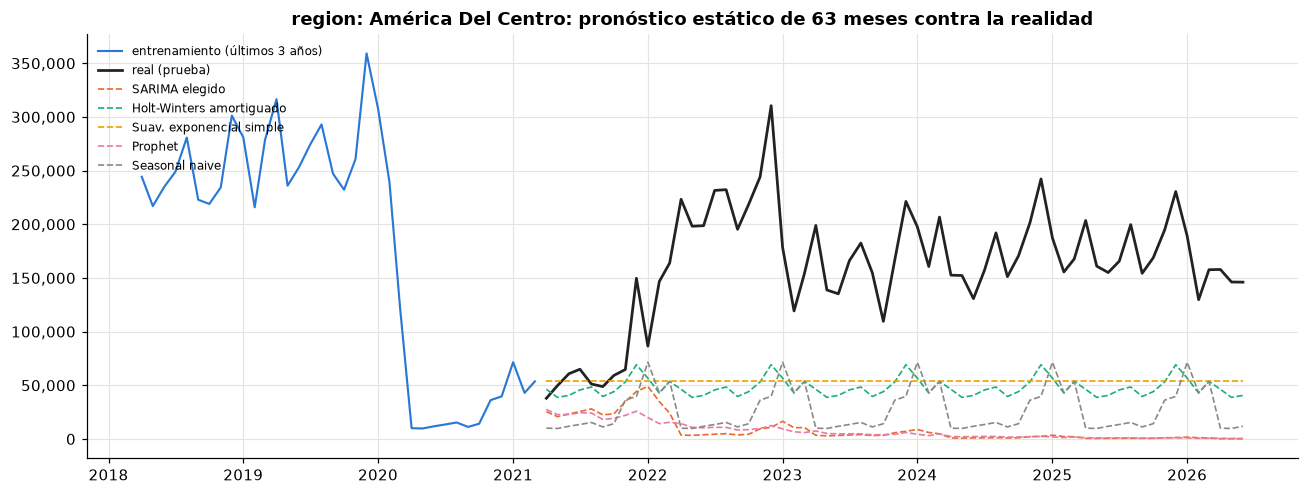

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,108285,120341,53656,161081
Holt-Winters amortiguado,113417,124216,47929,161081
Holt-Winters,118481,129415,42863,161081
Seasonal naive,134400,144899,26681,161081
SARIMA elegido,152689,164480,8392,161081
Prophet,153632,164424,7449,161081


In [18]:
preds_centro = pronosticos_alternativos("region: América Del Centro", mejor_centro)
graficar_pronosticos("region: América Del Centro", preds_centro, "modelado-centro-pronosticos")
tabla_errores("region: América Del Centro", preds_centro)

Mismo cuadro que el total, como era de esperar en la región que lo domina. Suavizamiento simple
al frente (108,285) contra un nivel real de 161,081, seguido de los Holt-Winters, con SARIMA
(152,689) y Prophet (153,632) al fondo. Anclaje puro.

### 7.3 América Del Norte

20:39:46 - cmdstanpy - INFO - Chain [1] start processing


20:39:46 - cmdstanpy - INFO - Chain [1] done processing


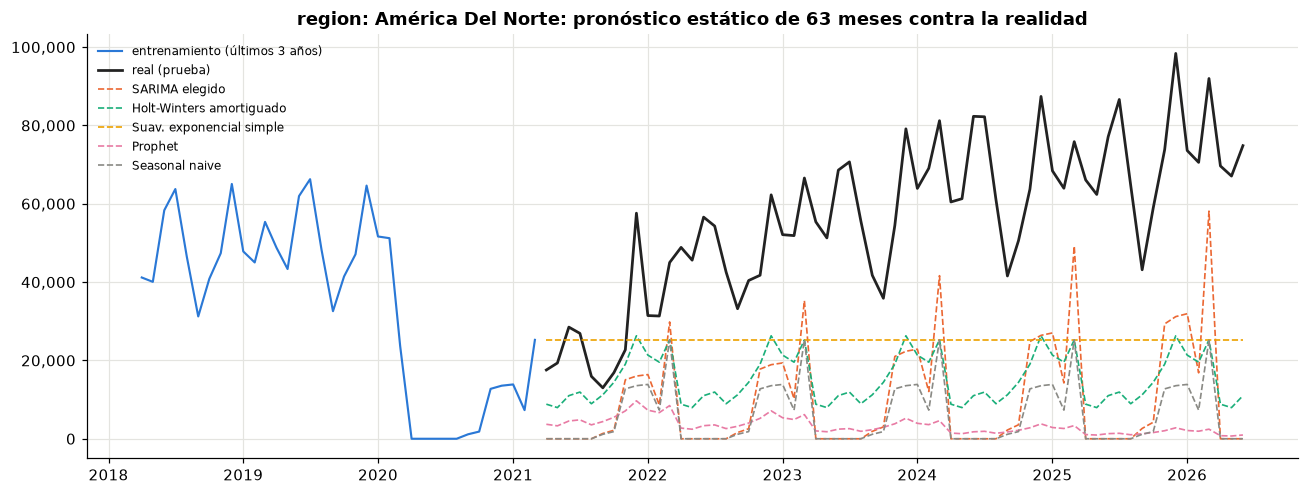

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,32194,36725,25250,55982
Holt-Winters amortiguado,40797,44975,15185,55982
Holt-Winters,42516,46845,13466,55982
SARIMA elegido,45796,49599,10186,55982
Seasonal naive,49974,53533,6008,55982
Prophet,52705,56698,3277,55982


In [19]:
preds_norte = pronosticos_alternativos("region: América Del Norte", mejor_norte)
graficar_pronosticos("region: América Del Norte", preds_norte, "modelado-norte-pronosticos")
tabla_errores("region: América Del Norte", preds_norte)

Norte recuperó más rápido, así que el cuadro es algo menos plano, pero la conclusión no cambia.
Suavizamiento simple gana (32,194) contra un nivel real de 55,982. Aquí el **SARIMA estático se
comporta bien** (45,796), sin rastro de la inestabilidad que aparecerá en la predicción a un
paso, porque el pronóstico multipaso propaga sus propias predicciones suaves y nunca toca los
meses en cero. El seasonal naive (49,974), que repite el último año, arrastra parte del piso
pandémico.

### 7.4 Europa

20:39:46 - cmdstanpy - INFO - Chain [1] start processing


20:39:46 - cmdstanpy - INFO - Chain [1] done processing


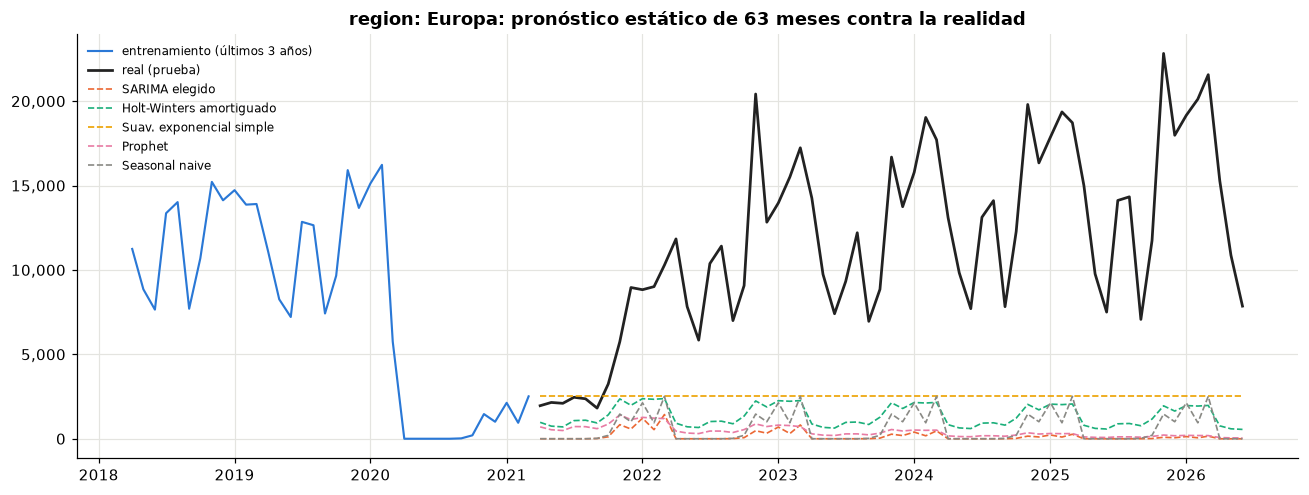

,MAE,RMSE,pred. media,real medio
Suav. exponencial simple,9292,10695,2511,11732
Holt-Winters amortiguado,10378,11563,1355,11732
Holt-Winters,10625,11853,1108,11732
Seasonal naive,11075,12135,657,11732
Prophet,11310,12577,422,11732
SARIMA elegido,11569,12760,163,11732


In [20]:
preds_europa = pronosticos_alternativos("region: Europa", mejor_europa)
graficar_pronosticos("region: Europa", preds_europa, "modelado-europa-pronosticos")
tabla_errores("region: Europa", preds_europa)

La serie más pequeña repite el patrón: suavizamiento simple al frente (9,292) contra un nivel
real de 11,732, y el resto agrupado detrás en un rango estrecho (10 a 12 mil). Con un nivel medio
tan bajo, todos los errores son de magnitud parecida y las diferencias entre algoritmos son ruido
de anclaje.

## 8. Predicción a un paso: la comparación que sí discrimina

Igual que en las fronteras, el pronóstico estático responde una pregunta que nadie haría en la
práctica: congelar el modelo en marzo 2021 y no volver a mirar los datos en cinco años. El uso
real es pronosticar el mes siguiente incorporando cada dato nuevo. Lo evaluamos con una predicción
a un paso tipo walk-forward: los parámetros del SARIMA quedan fijos (los del entrenamiento, sin
reestimar) y el filtro avanza mes a mes sobre la prueba prediciendo siempre el mes siguiente. Como
referencia usamos el seasonal naive a un paso, que predice cada mes con el valor real del mismo
mes del año anterior.

In [21]:
def sarima_un_paso(nombre, resultado):
    fwd, inv = TRANSFORM[nombre]
    serie_completa = fwd(pd.concat([train[nombre], test[nombre]]))
    filtrado = resultado.apply(serie_completa)  # mismos parámetros, filtro sobre toda la serie
    pred = inv(filtrado.get_prediction(start=test.index[0], dynamic=False).predicted_mean)
    return pred


filas = []
for nombre, resultado in [("total", mejor_total),
                          ("region: América Del Centro", mejor_centro),
                          ("region: América Del Norte", mejor_norte),
                          ("region: Europa", mejor_europa)]:
    yt = test[nombre]
    p_sarima = sarima_un_paso(nombre, resultado)
    p_naive = pd.concat([train[nombre], yt]).shift(12).loc[test.index]
    for etiq, p in [("SARIMA (1 paso)", p_sarima), ("Seasonal naive (1 paso)", p_naive)]:
        e = yt.values - p.values
        filas.append({"serie": nombre.replace("region: ", ""), "modelo": etiq,
                      "MAE": round(np.mean(np.abs(e))), "RMSE": round(np.sqrt(np.mean(e ** 2)))})
pd.DataFrame(filas).set_index(["serie", "modelo"])

MAE     RMSE
serie              modelo                                  
total              SARIMA (1 paso)           50430    80789
                   Seasonal naive (1 paso)   65996    93379
América Del Centro SARIMA (1 paso)           39151    58820
                   Seasonal naive (1 paso)   54412    75789
América Del Norte  SARIMA (1 paso)          292502  2238807
                   Seasonal naive (1 paso)   13379    16064
Europa             SARIMA (1 paso)            3727     8172
                   Seasonal naive (1 paso)    3018     4203

El resultado separa a las cuatro series en dos grupos limpios, y coincide con la partición por
ceros que ya venía marcando todo el modelado.

**Las dos series limpias, el SARIMA gana en las dos métricas.** En el **total** el MAE del SARIMA
baja de 226,894 (estático) a **50,430**, un 21% del nivel medio, y le gana al naive a un paso
(65,996); en RMSE también (80,789 contra 93,379). En **América Del Centro** lo mismo, SARIMA
39,151 contra naive 54,412 en MAE, y 58,820 contra 75,789 en RMSE. Aquí el SARIMA gana de forma
inequívoca, sin la ambigüedad MAE/RMSE que sí aparecía en las fronteras: la estructura estacional
más el término de corrección le ganan al simple año anterior en las dos series grandes.

**Las dos series con ceros, el seasonal naive gana, y en Norte el SARIMA se vuelve inestable.**
En **Europa** el naive gana en ambas métricas (3,018 contra 3,727 en MAE, 4,203 contra 8,172 en
RMSE) por poco. En **América Del Norte** el SARIMA a un paso directamente **colapsa**: su MAE es
292,502, más de cinco veces el nivel real, con un pico de pronóstico de 17.8 millones de
visitantes en septiembre 2021. La causa es la interacción del `log(1 + x)` con la diferencia
estacional: la predicción a un paso usa los valores reales rezagados, y el rezago estacional cae
sobre el bloque de meses en cero de 2020. La diferencia estacional entre un mes de recuperación
(1,144 en septiembre 2020) y el cero de su vecino se dispara en escala logarítmica, y al invertir
con `expm1` explota. El pronóstico estático no sufría esto porque propaga sus propias predicciones
suaves en vez de los ceros reales. Es un modo de falla real del enfoque log(1 + x) sobre una serie
con un bloque de ceros, no un error de código, y descarta al SARIMA como modelo operativo para
Norte.

La lectura de fondo es la contraria a la del horizonte estático: para las series sin ceros, el
SARIMA no solo es competitivo sino el mejor una vez que ve el dato reciente; para las series con
un bloque de ceros, la transformación log(1 + x) lo vuelve frágil y el seasonal naive, que copia
el año real sin transformar, es la opción robusta.

## 9. Selección del mejor modelo por serie

Con las dos evaluaciones sobre la mesa, la selección del inciso 4k queda así:

| Serie | Estático 63 meses (menor MAE) | A un paso (menor MAE) | Modelo seleccionado |
|---|---|---|---|
| Total | Suav. exponencial simple (158,777) | SARIMA (50,430) | **SARIMA(0,1,1)(1,1,0)₁₂ en log** |
| América Del Centro | Suav. exponencial simple (108,285) | SARIMA (39,151) | **SARIMA(0,1,1)(1,1,0)₁₂ en log** |
| América Del Norte | Suav. exponencial simple (32,194) | Seasonal naive (13,379) | **Seasonal naive a un paso** |
| Europa | Suav. exponencial simple (9,292) | Seasonal naive (3,018) | **Seasonal naive a un paso** |

El criterio es el mismo que en las fronteras: el ranking estático premia el anclaje al último
nivel, no la comprensión de la serie, así que pesa menos; el ranking a un paso mide el uso
operativo real. Para el total y América Del Centro seleccionamos sus SARIMA, que ganan a un paso
en las dos métricas y traen estructura interpretable y residuos validados. Para América Del Norte
y Europa seleccionamos el seasonal naive: en Europa gana en ambas métricas, y en Norte no solo
gana sino que el SARIMA es numéricamente inestable bajo log(1 + x), lo que lo descalifica como
modelo operativo.

El patrón que deja la categoría de regiones es nítido y complementa al de las fronteras: **las
series sin ceros se modelan mejor con SARIMA, las series con un bloque de ceros se pronostican
mejor, y de forma más segura, con seasonal naive.** Dos advertencias cierran, iguales a las de
fronteras. Primera: ningún modelo entrenado con el corte del enunciado sirve para pronóstico
multianual; cualquier uso institucional requiere reentrenar con datos posteriores a la reapertura,
y en Norte y Europa además reconsiderar la transformación, porque los ceros de 2020 quedarán
siempre dentro del historial. Segunda: las métricas de Prophet no condenan al algoritmo sino la
extrapolación de una tendencia quebrada; con regresores de intervención su desempeño cambiaría.